# Data Preprocesing

Loading libraries 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Loading Data frame

In [2]:
df = pd.read_csv("Loan_Modelling.csv")
df.head()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


From the data, 
- categorical variable: Family, Education, Personal_Loan, Securities_Account,CD_Account, Online, CreditCard, ZIPCode
- Numerical Variable: Age, Experience, Income, CCAvg, Mortgage

In [3]:
df.dtypes

ID                      int64
Age                     int64
Experience              int64
Income                  int64
ZIPCode                 int64
Family                  int64
CCAvg                 float64
Education               int64
Mortgage                int64
Personal_Loan           int64
Securities_Account      int64
CD_Account              int64
Online                  int64
CreditCard              int64
dtype: object

Don't want to change the original data

In [4]:
df_clean = df.copy()

In [5]:
df_clean.isnull().sum()

ID                    0
Age                   0
Experience            0
Income                0
ZIPCode               0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal_Loan         0
Securities_Account    0
CD_Account            0
Online                0
CreditCard            0
dtype: int64

No missing values in the data

In [6]:
df.describe()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93169.257000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,1759.455086,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,90005.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


- experience cannot be in negative
- Numbers are too big in income, zipcode, Mortgage
- Max is huge compared to mean can be a outliers (Age, Experience, Income, Zipcode, Family, CCAvg, Education, Mortgage)

In [7]:
df_clean["Experience"] = df_clean["Experience"].clip(lower=0)

In [8]:
df_clean.duplicated().sum()

np.int64(0)

- No duplicates found

- Univariate analysis

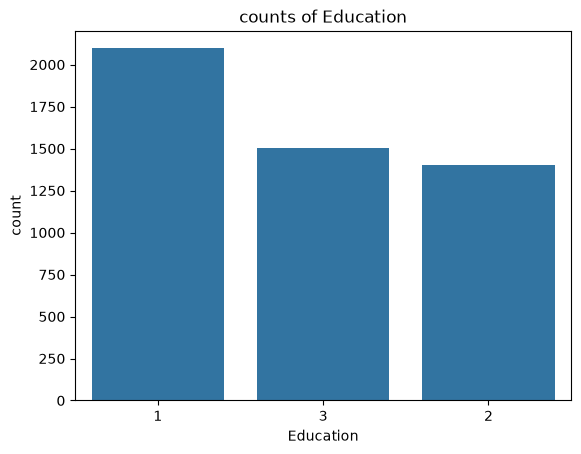

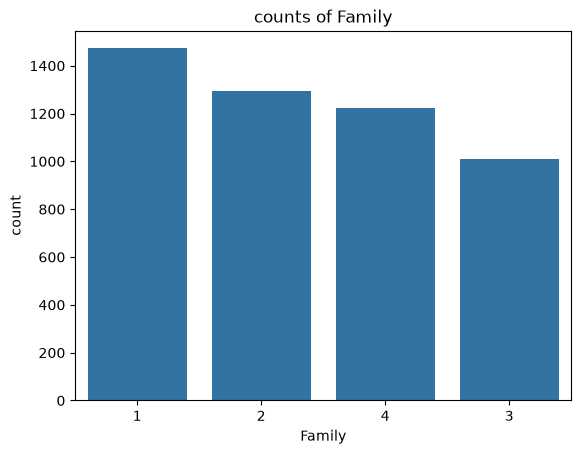

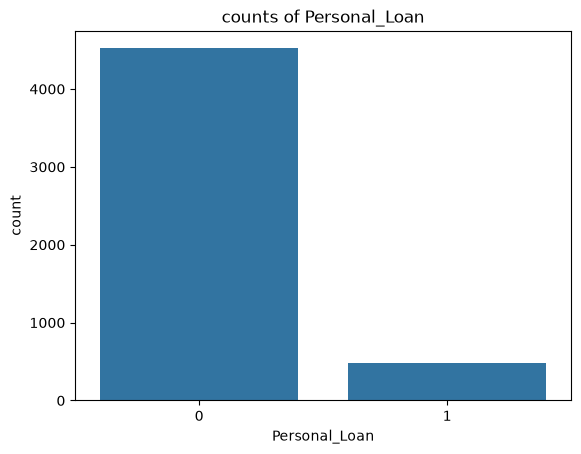

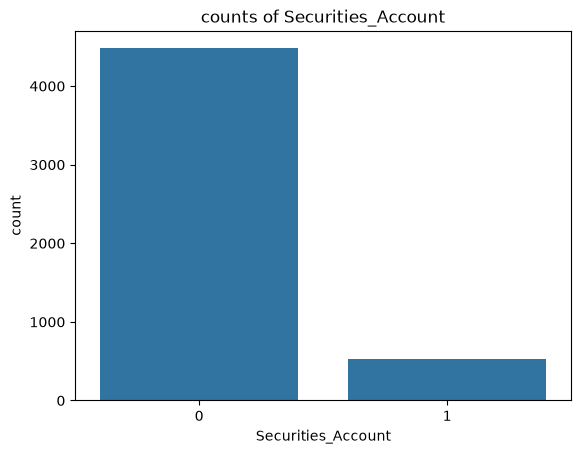

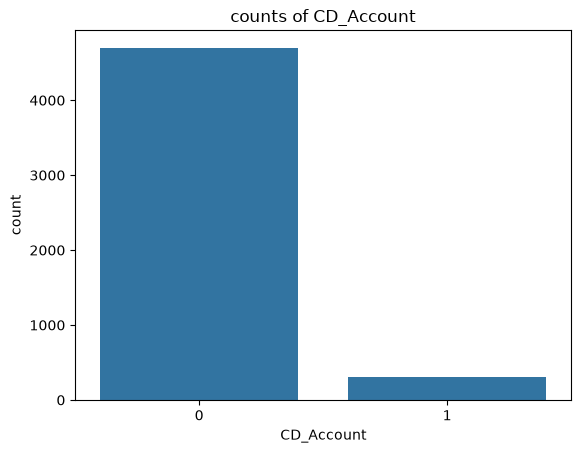

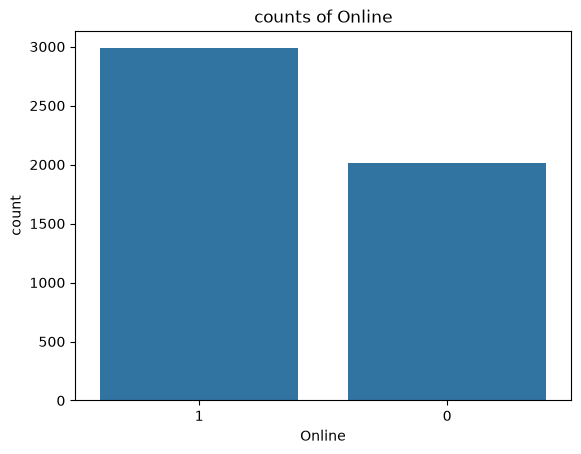

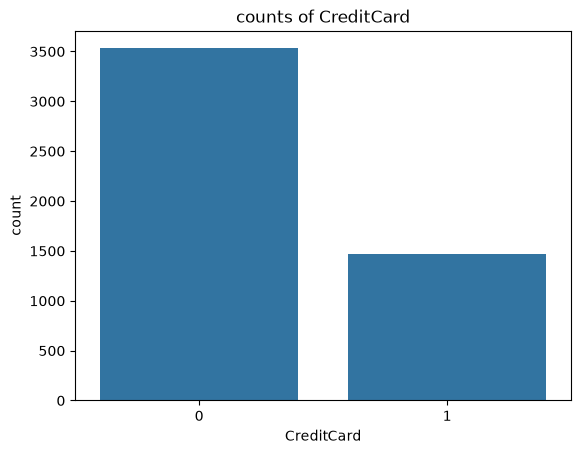

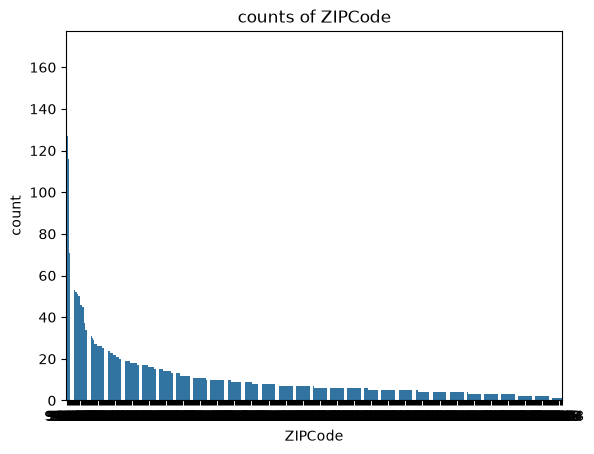

In [9]:
# For categorical distribution
for c in ["Education", "Family", "Personal_Loan", "Securities_Account", "CD_Account", "Online", "CreditCard", "ZIPCode"]:
    sns.countplot(x=c, data=df, order=df[c].value_counts().index)
    plt.title(f"counts of {c}")
    plt.show()

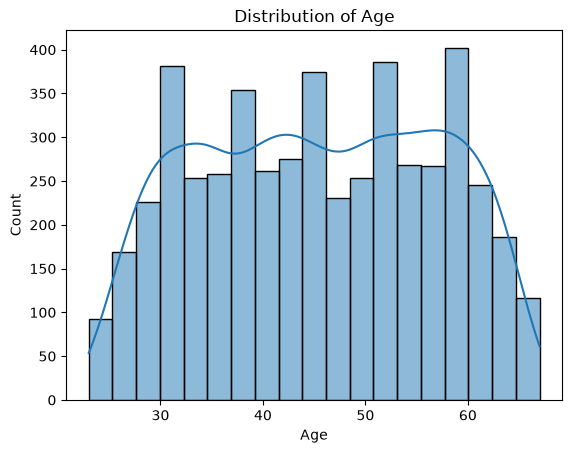

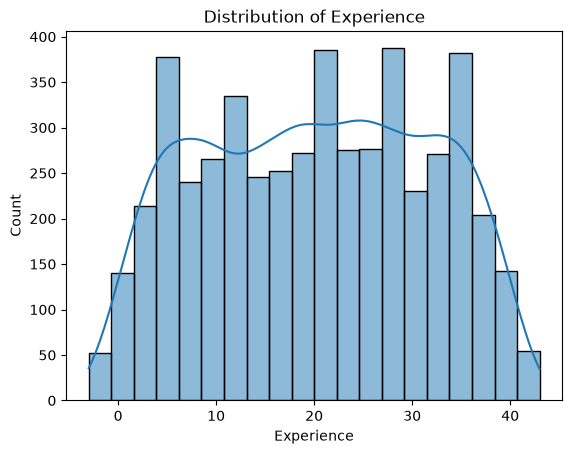

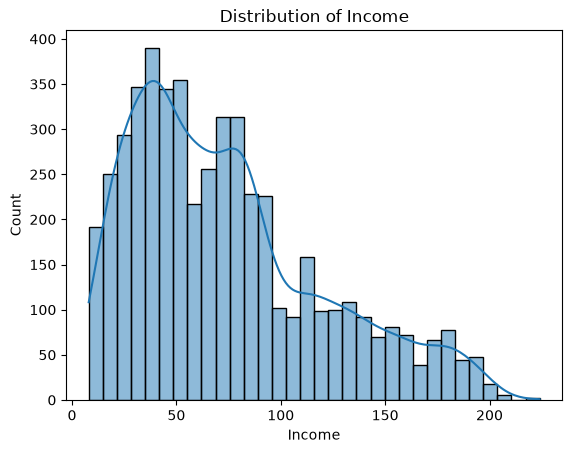

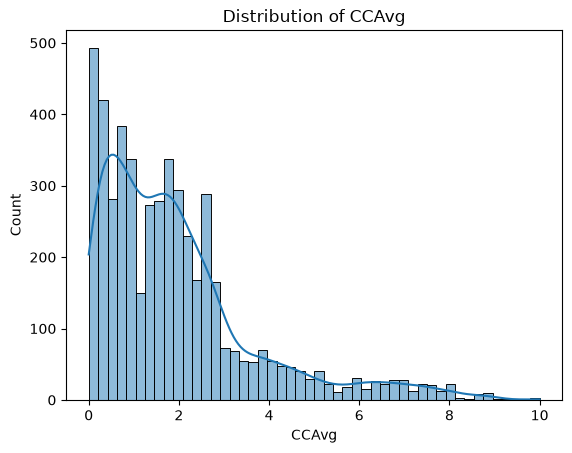

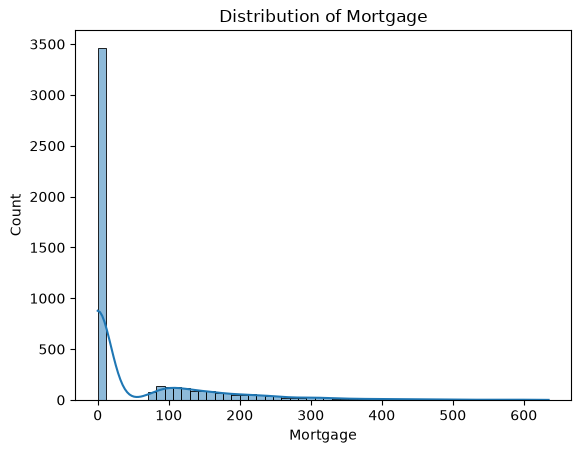

In [10]:
#For numerical Distribution
for x in ["Age", "Experience", "Income", "CCAvg", "Mortgage"]:
    sns.histplot(df[x], kde=True)
    plt.title(f"Distribution of {x}")
    plt.show()

- Bivariate analysis

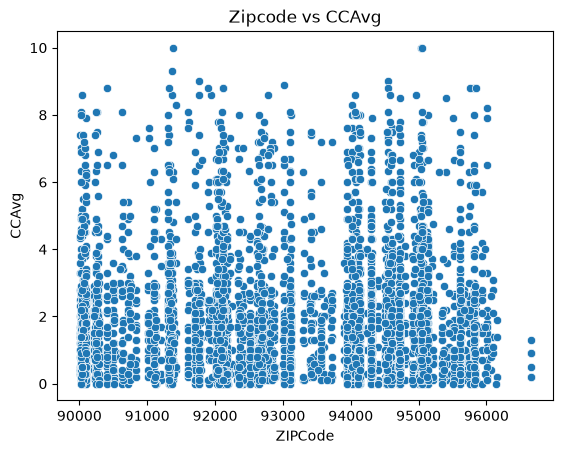

In [11]:
sns.scatterplot(x = "ZIPCode", y= "CCAvg", data=df )
plt.title("Zipcode vs CCAvg")
plt.show()

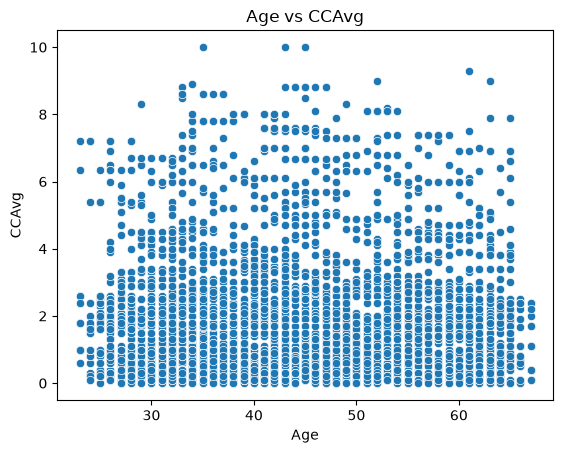

In [12]:
sns.scatterplot(x = "Age", y= "CCAvg", data=df )
plt.title("Age vs CCAvg")
plt.show()

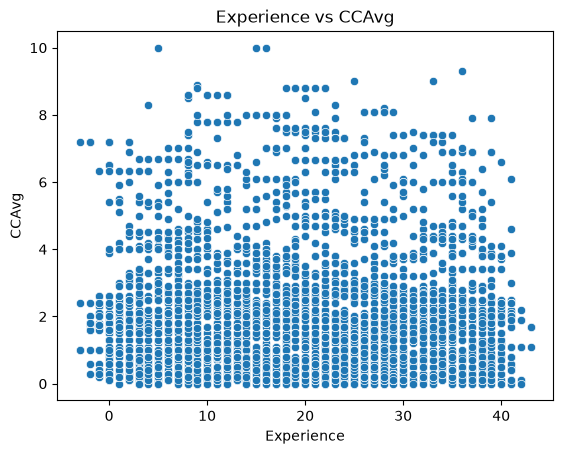

In [13]:
sns.scatterplot(x = "Experience", y= "CCAvg", data=df )
plt.title("Experience vs CCAvg")
plt.show()

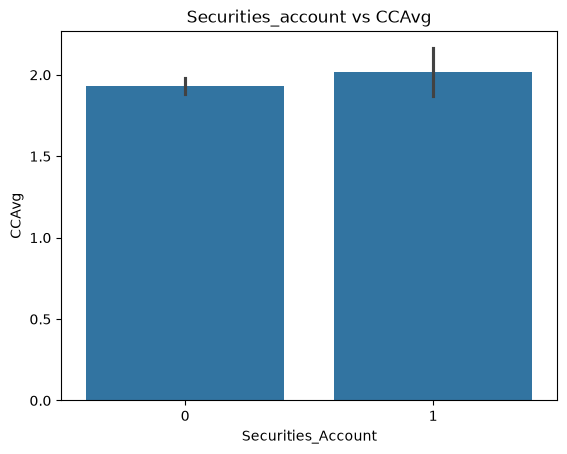

In [14]:
sns.barplot(x = "Securities_Account", y= "CCAvg", data=df )
plt.title("Securities_account vs CCAvg")
plt.show()

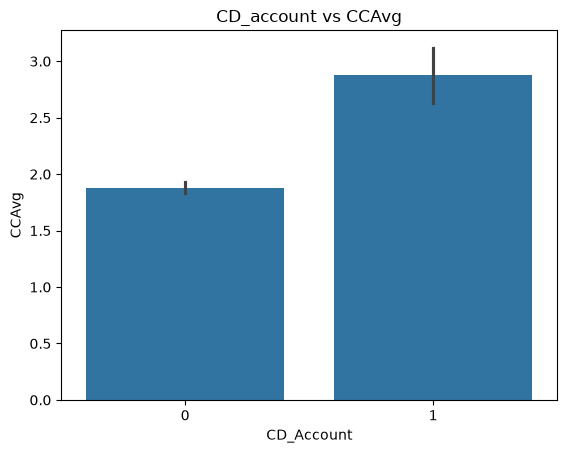

In [15]:
sns.barplot(x = "CD_Account", y= "CCAvg", data=df )
plt.title("CD_account vs CCAvg")
plt.show()

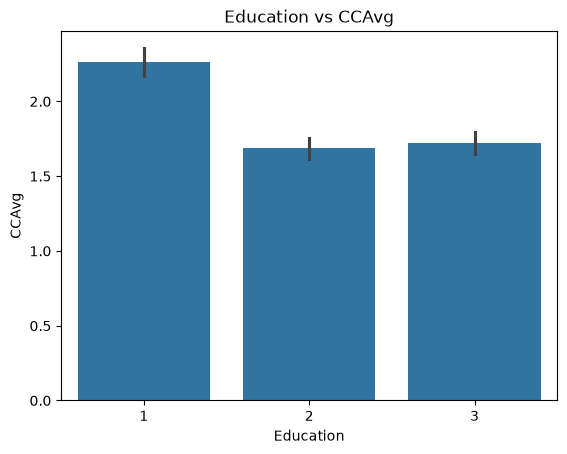

In [16]:
sns.barplot(x = "Education", y= "CCAvg", data=df )
plt.title("Education vs CCAvg")
plt.show()

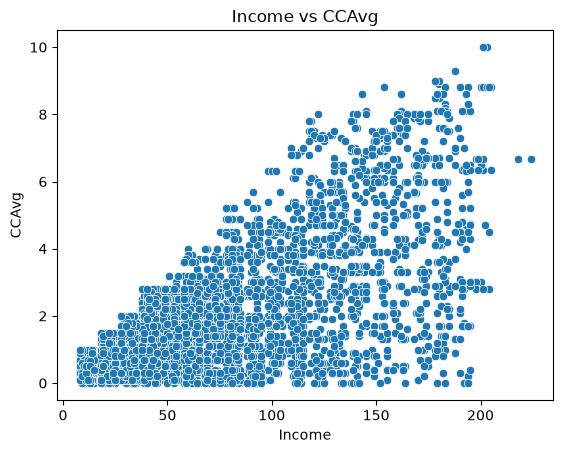

In [17]:
sns.scatterplot(x = "Income", y= "CCAvg", data=df )
plt.title("Income vs CCAvg")
plt.show()

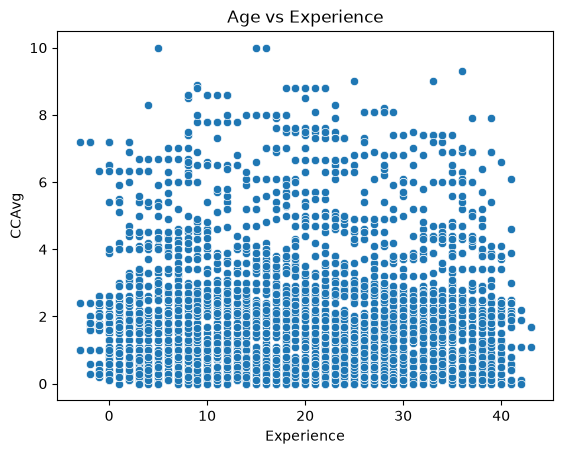

In [18]:
sns.scatterplot(x = "Experience", y= "CCAvg", data=df )
plt.title("Age vs Experience")
plt.show()

- Multivariate analysis

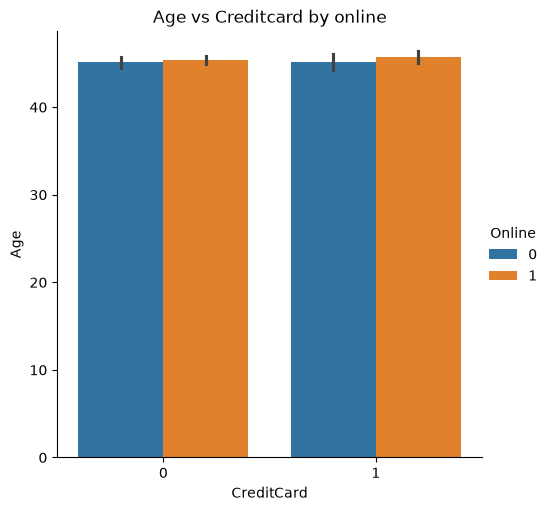

In [19]:
sns.catplot(x="CreditCard", y="Age", hue="Online", kind="bar", data=df)
plt.title('Age vs Creditcard by online')
plt.show()

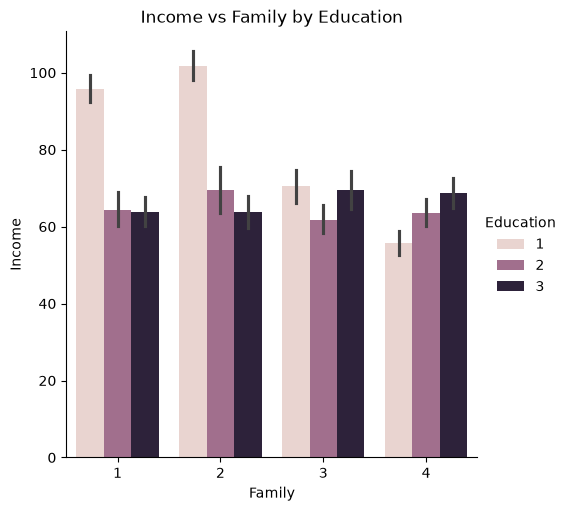

In [20]:
sns.catplot(x="Family", y="Income", hue="Education", kind="bar", data=df)
plt.title('Income vs Family by Education')
plt.show()

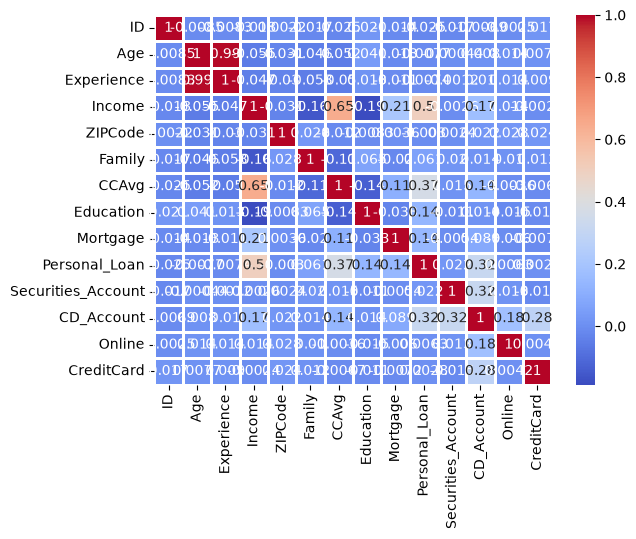

In [21]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", linewidths=1.0)
plt.show()

- All the variables are corelated to each other
- Age and Experience is positively corelated.

- Detecting outliers using boxplot

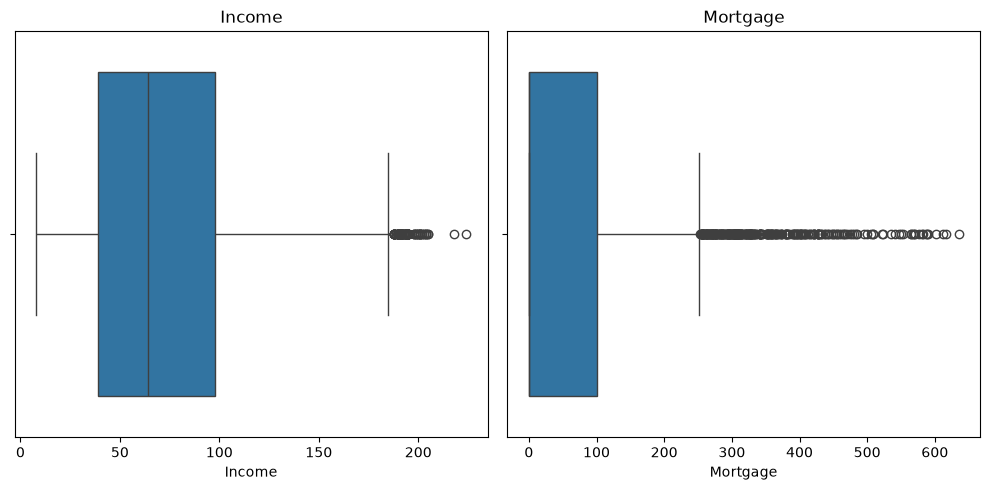

In [22]:
#Family, Education, Personal_Loan, Securities_Account,CD_Account, Online, CreditCard, ZIPCode
fig, axes = plt.subplots(1, 2, figsize = (10,5))
sns.boxplot(x=df_clean["Income"], ax=axes[0]); axes[0].set_title("Income")
sns.boxplot(x=df_clean["Mortgage"], ax = axes[1]); axes[1].set_title("Mortgage")
plt.tight_layout()
plt.show()

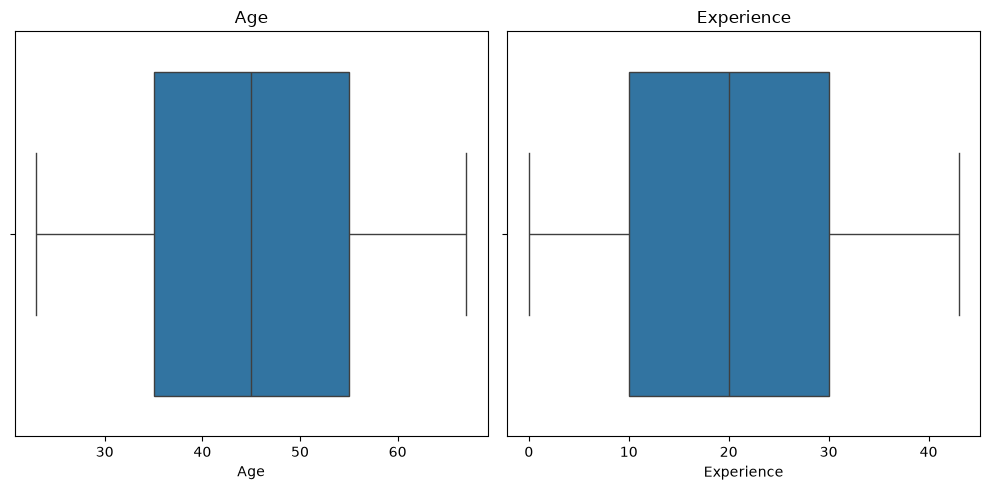

In [23]:
#Age, Experience, Income, CCAvg, Mortgage
fig1, axes1 = plt.subplots(1, 2, figsize = (10,5))
sns.boxplot(x=df_clean["Age"], ax=axes1[0]); axes1[0].set_title("Age")
sns.boxplot(x=df_clean["Experience"], ax = axes1[1]); axes1[1].set_title("Experience")
plt.tight_layout()
plt.show()

- Income and Mortgage have outliers

- Finding outliers using IQR (interquartile range)

In [24]:
def iqr_bounds(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5*iqr, q3 + 1.5*iqr

low, high = iqr_bounds(df_clean["Income"])
low1, high1 = iqr_bounds(df_clean["Mortgage"])

print(f"Income bounds: {low:,.0f} to {high:,.0f}")
print("Income outliers:", ((df_clean["Income"] < low) | (df_clean["Income"] > high)).sum())

print(f"Mortgage bounds: {low1:,.0f} to {high1:,.0f}")
print("Mortgage outliers:", ((df_clean["Mortgage"] < low1) | (df_clean["Mortgage"] > high1)).sum())

# Look at the flagged rows before deciding anything!
df_clean[(df_clean["Income"] < low) | (df_clean["Income"] > high)][
    ["ID","Age","Experience","Education","CreditCard","Personal_Loan","Mortgage"]]


Income bounds: -50 to 186
Income outliers: 96
Mortgage bounds: -152 to 252
Mortgage outliers: 291


,ID,Age,Experience,Education,CreditCard,Personal_Loan,Mortgage
18,19,46,21,3,0,1,0
47,48,37,12,3,1,1,211
53,54,50,26,3,0,1,240
59,60,31,5,1,0,0,455
303,304,49,25,1,0,1,617
...,...,...,...,...,...,...,...
4659,4660,28,4,1,0,0,0
4670,4671,52,26,1,0,0,0
4895,4896,45,20,1,1,0,0
4981,4982,34,9,1,0,0,122


In [25]:
df_clean[(df_clean["Mortgage"] < low1) | (df_clean["Mortgage"] > high1)][
    ["ID","Age","Experience","Education","CreditCard","Personal_Loan","Income"]]

,ID,Age,Experience,Education,CreditCard,Personal_Loan,Income
22,23,29,5,1,0,0,62
39,40,38,13,3,0,0,80
42,43,32,7,2,0,1,132
59,60,31,5,1,0,0,188
66,67,62,36,1,0,0,105
...,...,...,...,...,...,...,...
4859,4860,34,8,3,0,1,165
4865,4866,50,24,2,1,1,133
4899,4900,54,29,3,0,0,85
4942,4943,52,26,1,1,0,109


- Detecting outliers with Z score

In [26]:
z = (df_clean["Income"] - df_clean["Income"].mean()) / df_clean["Income"].std()

print("Income values with |z| > 3:")
print(df_clean.loc[z.abs() > 3, "Income"].to_string())
print("\nCompare: IQR flagged", ((df_clean["Income"] < low) | (df_clean["Income"] > high)).sum(),
      "rows; Z-score flagged", (z.abs() > 3).sum(), "rows")

Income values with |z| > 3:
3896    224
4993    218

Compare: IQR flagged 96 rows; Z-score flagged 2 rows


In [27]:
z = (df_clean["Mortgage"] - df_clean["Mortgage"].mean()) / df_clean["Mortgage"].std()

print("Mortgage values with |z| > 3:")
print(df_clean.loc[z.abs() > 3, "Mortgage"].to_string())
print("\nCompare: IQR flagged", ((df_clean["Mortgage"] < low1) | (df_clean["Mortgage"] > high1)).sum(),
      "rows; Z-score flagged", (z.abs() > 3).sum(), "rows")

Mortgage values with |z| > 3:
42      412
59      455
119     366
288     391
303     617
327     402
338     392
354     419
365     466
459     458
473     547
479     470
528     378
570     485
679     364
684     449
782     587
888     372
952     524
1023    366
1111    442
1162    394
1167    475
1273    437
1277    428
1288    366
1303    382
1304    397
1328    380
1359    433
1372    483
1623    455
1674    421
1716    565
1736    394
1783    601
1789    567
1875    389
1889    372
1937    589
1970    397
2027    380
2041    535
2076    398
2217    446
2319    422
2382    428
2394    505
2422    400
2443    422
2541    569
2590    374
2653    408
2668    406
2687    452
2714    432
2753    477
2768    396
2769    582
2776    380
2812    467
2841    565
2934    635
2942    385
2946    437
2956    522
2989    496
3012    415
3020    392
3021    461
3065    368
3209    373
3304    383
3357    408
3373    442
3411    427
3467    364
3470    429
3472    431
3515    508
3571    41

- Treating outliers with log transform for skewness

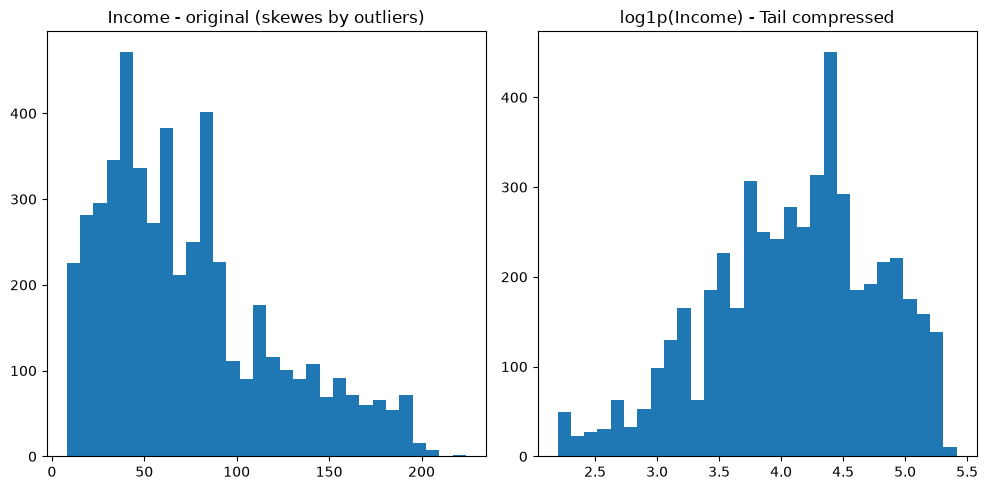

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))
axes[0].hist(df_clean["Income"].dropna(), bins=30)
axes[0].set_title("Income - original (skewes by outliers)")

axes[1].hist(np.log1p(df_clean["Income"].dropna()), bins=30)
axes[1].set_title("log1p(Income) - Tail compressed")
plt.tight_layout()
plt.show()

In [29]:
df_clean["Income"] = np.log1p(df_clean["Income"])

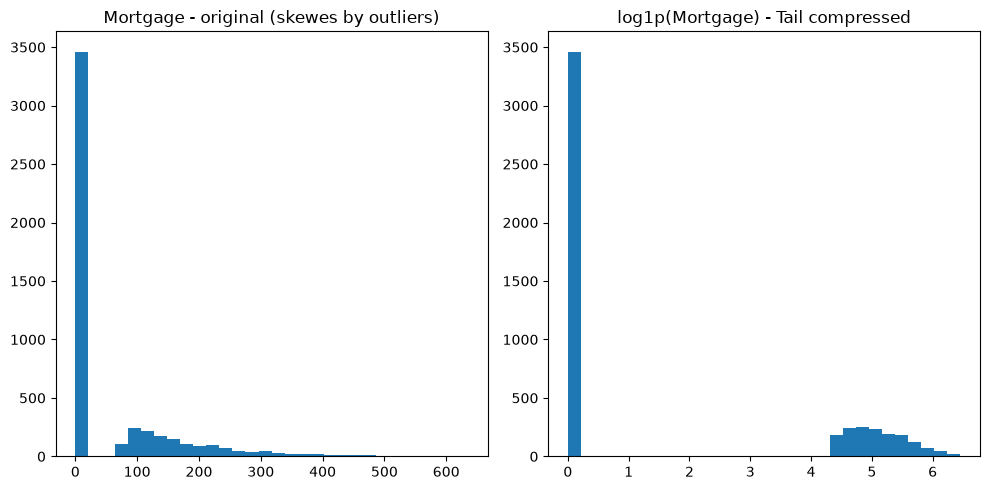

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))
axes[0].hist(df_clean["Mortgage"].dropna(), bins=30)
axes[0].set_title("Mortgage - original (skewes by outliers)")

axes[1].hist(np.log1p(df_clean["Mortgage"].dropna()), bins=30)
axes[1].set_title("log1p(Mortgage) - Tail compressed")
plt.tight_layout()
plt.show()

In [ ]:
df_clean["Mortgage"] = np.log1p(df_clean["Mortgage"])

- Encoding categorical Variables

- using one hot encoding for ZIPCode

In [31]:
df_clean = pd.get_dummies(df_clean, columns=["ZIPCode"], drop_first=True)
print("Columns after encoding:")
print(list(df_clean.columns))
df_clean.head()

Columns after encoding:
['ID', 'Age', 'Experience', 'Income', 'Family', 'CCAvg', 'Education', 'Mortgage', 'Personal_Loan', 'Securities_Account', 'CD_Account', 'Online', 'CreditCard', 'ZIPCode_90007', 'ZIPCode_90009', 'ZIPCode_90011', 'ZIPCode_90016', 'ZIPCode_90018', 'ZIPCode_90019', 'ZIPCode_90024', 'ZIPCode_90025', 'ZIPCode_90027', 'ZIPCode_90028', 'ZIPCode_90029', 'ZIPCode_90032', 'ZIPCode_90033', 'ZIPCode_90034', 'ZIPCode_90035', 'ZIPCode_90036', 'ZIPCode_90037', 'ZIPCode_90041', 'ZIPCode_90044', 'ZIPCode_90045', 'ZIPCode_90048', 'ZIPCode_90049', 'ZIPCode_90057', 'ZIPCode_90058', 'ZIPCode_90059', 'ZIPCode_90064', 'ZIPCode_90065', 'ZIPCode_90066', 'ZIPCode_90068', 'ZIPCode_90071', 'ZIPCode_90073', 'ZIPCode_90086', 'ZIPCode_90089', 'ZIPCode_90095', 'ZIPCode_90210', 'ZIPCode_90212', 'ZIPCode_90230', 'ZIPCode_90232', 'ZIPCode_90245', 'ZIPCode_90250', 'ZIPCode_90254', 'ZIPCode_90266', 'ZIPCode_90272', 'ZIPCode_90274', 'ZIPCode_90275', 'ZIPCode_90277', 'ZIPCode_90280', 'ZIPCode_90291', '

,ID,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,...,ZIPCode_95973,ZIPCode_96001,ZIPCode_96003,ZIPCode_96008,ZIPCode_96064,ZIPCode_96091,ZIPCode_96094,ZIPCode_96145,ZIPCode_96150,ZIPCode_96651
0,1,25,1,3.912023,4,1.6,1,0,0,1,...,False,False,False,False,False,False,False,False,False,False
1,2,45,19,3.555348,3,1.5,1,0,0,1,...,False,False,False,False,False,False,False,False,False,False
2,3,39,15,2.484907,1,1.0,1,0,0,0,...,False,False,False,False,False,False,False,False,False,False
3,4,35,9,4.615121,1,2.7,2,0,0,0,...,False,False,False,False,False,False,False,False,False,False
4,5,35,8,3.828641,4,1.0,2,0,0,0,...,False,False,False,False,False,False,False,False,False,False


In [32]:
df_clean.shape
df_clean.columns

Index(['ID', 'Age', 'Experience', 'Income', 'Family', 'CCAvg', 'Education',
       'Mortgage', 'Personal_Loan', 'Securities_Account',
       ...
       'ZIPCode_95973', 'ZIPCode_96001', 'ZIPCode_96003', 'ZIPCode_96008',
       'ZIPCode_96064', 'ZIPCode_96091', 'ZIPCode_96094', 'ZIPCode_96145',
       'ZIPCode_96150', 'ZIPCode_96651'],
      dtype='str', length=479)

- Feature scaling

In [33]:
from sklearn.preprocessing import MinMaxScaler
num_cols = ["Age", "Income", "Mortgage"]

minmax   = MinMaxScaler().fit_transform(df_clean[num_cols])
print("\nMinMaxScaler -> values in [0, 1]:")
print(pd.DataFrame(minmax, columns=num_cols).describe().loc[["min", "max"]].round(2))



MinMaxScaler -> values in [0, 1]:
     Age  Income  Mortgage
min  0.0     0.0       0.0
max  1.0     1.0       1.0


In [34]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=["CCAvg", "ID","Experience"])
y = df_clean["CCAvg"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (4000, 476)  Test: (1000, 476)


In [35]:
from sklearn.linear_model import LinearRegression

lin_reg_model1 = LinearRegression()
lin_reg_model1.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](476,)","[-0.01, 1.29,-0.09,..., 0.37,-1.42,-0.77]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](476,)","['Age','Income','Family',...,'ZIPCode_96145','ZIPCode_96150', 'ZIPCode_96651']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.399
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,476
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(472)


# model performance check function

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))

# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
        },
        index=[0],
    )

    return df_perf

In [39]:
# Checking model performance on train set
print("Training Performance:")
lin_reg_model1_perf_train = model_performance_regression(
    lin_reg_model1, X_train, y_train
)
lin_reg_model1_perf_train

Training Performance:


,RMSE,MAE,R-squared,Adj. R-squared
0,1.295966,0.943929,0.45115,0.376993


In [40]:
# Checking model performance on test set
print("Test Performance:")
lin_reg_model1_perf_test = model_performance_regression(lin_reg_model1, X_test, y_test)
lin_reg_model1_perf_test

Test Performance:


,RMSE,MAE,R-squared,Adj. R-squared
0,1.469039,1.072062,0.287118,-0.361699


An $R^2$ of 0.3737 means model captures roughly 37.4% variations that drive a customer's card spending.

MAE Interpretation (1.0142): On average, your model's predictions miss a customer's true monthly credit card spend by roughly $1,014.

RMSE Interpretation (1.29595): RMSE is highly sensitive to extreme outliers because it squares errors before averaging them. Your RMSE ($1,2959) is higher than your MAE ($9439).

In [41]:
#storing the predicted CCAvg for stage 2 classification
x1 = df_clean.drop(columns=["CCAvg", "ID","Experience"])
all_predictions = lin_reg_model1.predict(x1)
df_clean['Predicted_CCAvg'] = all_predictions

df_clean.head()

,ID,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,...,ZIPCode_96001,ZIPCode_96003,ZIPCode_96008,ZIPCode_96064,ZIPCode_96091,ZIPCode_96094,ZIPCode_96145,ZIPCode_96150,ZIPCode_96651,Predicted_CCAvg
0,1,25,1,3.912023,4,1.6,1,0,0,1,...,False,False,False,False,False,False,False,False,False,1.475816
1,2,45,19,3.555348,3,1.5,1,0,0,1,...,False,False,False,False,False,False,False,False,False,1.501838
2,3,39,15,2.484907,1,1.0,1,0,0,0,...,False,False,False,False,False,False,False,False,False,0.010069
3,4,35,9,4.615121,1,2.7,2,0,0,0,...,False,False,False,False,False,False,False,False,False,2.331519
4,5,35,8,3.828641,4,1.0,2,0,0,0,...,False,False,False,False,False,False,False,False,False,1.112547


In [45]:
X_stage2 = df_clean.drop(columns=["Personal_Loan", "CCAvg", "ID"])
y_stage2 = df_clean["Personal_Loan"]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X_stage2, y_stage2, test_size=0.2, random_state=42
)
print(X2_train.shape,X2_test.shape)

(4000, 477) (1000, 477)


In [46]:
from sklearn.linear_model import LogisticRegression

clf_model = LogisticRegression(class_weight="balanced", random_state=42)
clf_model.fit(X2_train, y2_train)

c:\Users\pooja\Training\week 2 assessment\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default

In [47]:
#check performance
from sklearn.metrics import classification_report, roc_auc_score

y2_pred = clf_model.predict(X2_test)
y2_proba = clf_model.predict_proba(X2_test)[:, 1]
print("\nClassification Evaluation Metrics:")
print(classification_report(y2_test, y2_pred))
print(f"ROC-AUC Performance Score:   {roc_auc_score(y2_test, y2_proba):.4f}")


Classification Evaluation Metrics:
              precision    recall  f1-score   support

           0       1.00      0.93      0.96       895
           1       0.62      0.98      0.76       105

    accuracy                           0.94      1000
   macro avg       0.81      0.96      0.86      1000
weighted avg       0.96      0.94      0.94      1000

ROC-AUC Performance Score:   0.9773


- Precision = 0.66: When the model tags someone as a target, it is correct 66% of the time. The remaining 51% are False Positives (people called who say no).

- Recall = 0.98: Your model successfully captured 98% of all real potential borrowers in the test set. It only missed 2% of them (False Negatives).

- F1-score = 0.79. This reflects the balanced compromise we forced upon the model by using class_weight='balanced' to offset the extreme rarity of loan takers.

- ROC-AUC curve = 0.98. It tells the executive suite that if you randomly pull one depositor who wants a loan and one who doesn't, there is a 94.5% chance the model will correctly assign a higher score to the true prospective borrower.